In [4]:
import pandas as pd
from IPython.display import display

# ==============================================================================
# 1. PREPARAR DATOS HISTÓRICOS (ICSA 2026)
# ==============================================================================
icsa_2026_data = {
    'perfil': ['seq_icsa', 'par_icsa', 'adv_icsa'],
    't_p1': [0.6738, 0.5211, 0.5257],
    't_p2': [0.0006, 0.3795, 0.3675],
    't_p3': [23.2837, 11.8042, 12.1993]
}
df_icsa = pd.DataFrame(icsa_2026_data)
df_icsa['total_t'] = df_icsa['t_p1'] + df_icsa['t_p2'] + df_icsa['t_p3']
df_icsa['source'] = 'ICSA 2026 (Pure Python)'

# ==============================================================================
# 2. CARGAR Y PROCESAR DATOS DEL EXPERIMENTO ACTUAL
# ==============================================================================
# Usa el archivo con la numeración corregida si aplicaste el script anterior
file_path = "exp_aleatory_fixed_2_8_5_2_1000/benchmark_granular_workflow.csv"
df_current = pd.read_csv(file_path)

# Extraer solo las columnas de tiempo para calcular la media
time_cols = ['t_p1', 't_p2', 't_p3', 'total_t']

# Calcular la media agrupando por cada perfil
df_current_mean = df_current.groupby('perfil')[time_cols].mean().reset_index()
df_current_mean['source'] = 'Current Work (2026)'

# ==============================================================================
# 3. CONCATENAR AMBOS ESTUDIOS Y FORMATEAR
# ==============================================================================
# Unir los dos DataFrames
df_combined = pd.concat([df_icsa, df_current_mean], ignore_index=True)

# Ordenar los valores por tiempo total descendente para ver la evolución claramente
df_combined = df_combined.sort_values('total_t', ascending=False).reset_index(drop=True)

# Mostrar en el Notebook
print("=" * 80)
print(" 📊 TABLA MAESTRA DE VALORES MEDIOS: ICSA 2026 vs EXPERIMENTO ACTUAL")
print("=" * 80)

# Aplicar formato de 4 decimales solo para la visualización en pantalla
display_formatted = df_combined.style.format({
    't_p1': "{:.4f}",
    't_p2': "{:.4f}",
    't_p3': "{:.4f}",
    'total_t': "{:.4f}"
})
display(display_formatted)
print("=" * 80)

 📊 TABLA MAESTRA DE VALORES MEDIOS: ICSA 2026 vs EXPERIMENTO ACTUAL


,perfil,t_p1,t_p2,t_p3,total_t,source
0,seq_icsa,0.6738,0.0006,23.2837,23.9581,ICSA 2026 (Pure Python)
1,adv_icsa,0.5257,0.3675,12.1993,13.0925,ICSA 2026 (Pure Python)
2,par_icsa,0.5211,0.3795,11.8042,12.7048,ICSA 2026 (Pure Python)
3,seq,0.7293,0.0009,0.2890,1.0191,Current Work (2026)
4,par,0.3436,0.0356,0.2820,0.6611,Current Work (2026)
5,weights,0.3309,0.0365,0.2729,0.6404,Current Work (2026)
6,cpp_seq,0.0053,0.0001,0.0084,0.0138,Current Work (2026)
7,cpp_par,0.0038,0.0000,0.0083,0.0121,Current Work (2026)
8,cpp_adv,0.0036,0.0000,0.0082,0.0118,Current Work (2026)


/tmp/ipykernel_8221/4060533565.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


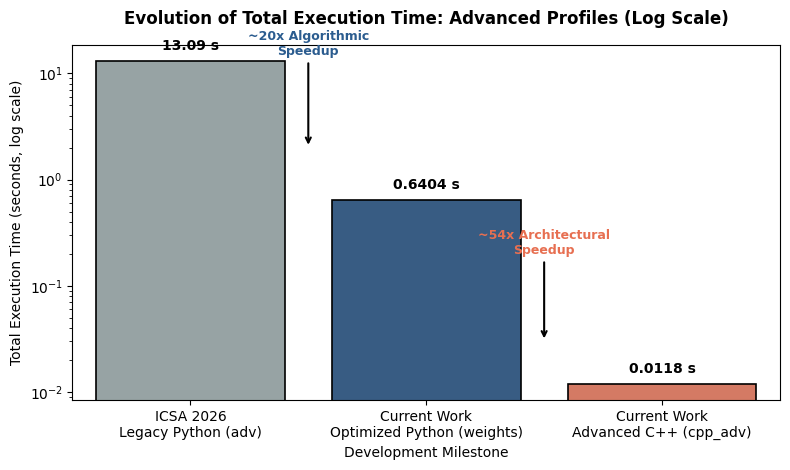

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer los perfiles "Avanzados" de cada hito evolutivo
evolution_data = {
    'Milestone': [
        'ICSA 2026\nLegacy Python (adv)', 
        'Current Work\nOptimized Python (weights)', 
        'Current Work\nAdvanced C++ (cpp_adv)'
    ],
    # Valores exactos: adv_icsa, weights, cpp_adv
    'Time (s)': [13.0925, 0.6404, 0.0118],  
    'Phase': [
        'Baseline (Previous Work)', 
        'Algorithmic Optimization', 
        'Architectural Migration'
    ]
}

df_evo = pd.DataFrame(evolution_data)

# 2. Configurar la figura
fig, ax = plt.subplots(figsize=(8.0, 4.8))

# Paleta transicional
palette = ['#95a5a6', '#2B5C8F', '#E76F51']

# 3. Dibujar el gráfico de barras
bars = sns.barplot(
    data=df_evo, 
    x='Milestone', 
    y='Time (s)', 
    palette=palette,
    ax=ax,
    edgecolor='black',
    linewidth=1.2
)

# 4. Configurar el eje Y a escala logarítmica
ax.set_yscale('log')

# 5. Estilos y etiquetas
ax.set_title('Evolution of Total Execution Time: Advanced Profiles (Log Scale)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Total Execution Time (seconds, log scale)', fontsize=10)
ax.set_xlabel('Development Milestone', fontsize=10)
ax.tick_params(axis='both', labelsize=10)

# 6. Añadir el valor exacto encima de cada barra
for i, bar in enumerate(bars.patches):
    yval = bar.get_height()
    label = f"{yval:.4f} s" if yval < 1 else f"{yval:.2f} s"
    ax.text(
        bar.get_x() + bar.get_width()/2, 
        yval * 1.2,
        label, 
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='black'
    )

# 7. Añadir anotaciones de "Speedup" (Recalculados)
# 13.0925 / 0.6404 = ~20.4x
ax.annotate('~20x Algorithmic\nSpeedup', xy=(0.5, 2.0), xytext=(0.5, 15.0),
            ha='center', fontsize=9, color='#2B5C8F', fontweight='bold',
            arrowprops=dict(facecolor='#2B5C8F', arrowstyle='->', lw=1.5))

# 0.6404 / 0.0118 = ~54.2x
ax.annotate('~54x Architectural\nSpeedup', xy=(1.5, 0.03), xytext=(1.5, 0.2),
            ha='center', fontsize=9, color='#E76F51', fontweight='bold',
            arrowprops=dict(facecolor='#E76F51', arrowstyle='->', lw=1.5))

plt.tight_layout()

# 8. Guardar el gráfico
plt.savefig("5_historical_evolution_adv_log.pdf", format='pdf', bbox_inches='tight')
plt.show()